In [14]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scripts import style
style.mpl_apply()

In [15]:
a=2

In [16]:
# --------- config ---------
BASE_DIR = Path("results/cleaned")  # folder with CSVs
ID_COL = "SamplingOperations_code"
LABEL_COL = "IBD_EQR_Status"

# Optional: normalize label strings to canonical classes
CANON = {"high":"High","good":"Good","moderate":"Moderate","bad":"Bad","poor":"Poor"}
ALIASES = {
    "hi":"High","hg":"High","h":"High",
    "go":"Good","g":"Good",
    "mod":"Moderate","m":"Moderate",
    "ba":"Bad","b":"Bad",
    "po":"Poor","p":"Poor"
}

In [17]:

def tidy_label(x):
    if x is None or (isinstance(x, float) and pd.isna(x)): return None
    s = str(x).strip().lower()
    s = re.sub(r"[_\-\s]+", " ", s)
    s = s.replace("class ", "").replace("status ", "")
    s = s.split()[0]  # keep first token (e.g., "good" from "good status")
    if s in CANON: return CANON[s]
    if s in ALIASES: return ALIASES[s]
    # try first-letter match to known classes
    if s[:1] in ALIASES: return ALIASES[s[:1]]
    return None  # unknown label → drop

In [18]:
def load_series_from_csv(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    # tolerate column name variants
    cols = {c.lower(): c for c in df.columns}
    idc = cols.get(ID_COL.lower(), None)
    lab = cols.get(LABEL_COL.lower(), None)
    if idc is None or lab is None:
        raise ValueError(f"File {path.name} missing required columns.")
    df = df[[idc, lab]].rename(columns={idc: ID_COL, lab: LABEL_COL})
    # deduplicate and clean
    df = df.dropna(subset=[ID_COL]).drop_duplicates(subset=[ID_COL], keep="first")
    df[LABEL_COL] = df[LABEL_COL].map(tidy_label)
    df = df.dropna(subset=[LABEL_COL])
    s = df.set_index(ID_COL)[LABEL_COL]
    s.name = path.stem  # label series with filename stem
    return s

In [19]:
def compute_pairwise_agreement(series_list: list[pd.Series]) -> tuple[pd.DataFrame, pd.DataFrame]:
    names = [s.name for s in series_list]
    n = len(series_list)
    agree = np.full((n, n), np.nan, dtype=float)
    counts = np.zeros((n, n), dtype=int)

    for i in range(n):
        si = series_list[i]
        for j in range(i, n):
            sj = series_list[j]
            idx = si.index.intersection(sj.index)
            counts[i, j] = counts[j, i] = len(idx)
            if len(idx) == 0:
                continue
            m = (si.loc[idx].values == sj.loc[idx].values)
            pct = float(np.mean(m)) * 100.0
            agree[i, j] = agree[j, i] = pct

    A = pd.DataFrame(agree, index=names, columns=names)
    N = pd.DataFrame(counts, index=names, columns=names)
    # set perfect diagonal
    for k in range(n):
        A.iat[k, k] = 100.0
    return A.round(2), N

In [20]:

y1 = pd.read_csv(BASE_DIR / "BC_acc=0.820462.csv")
y2 = pd.read_csv(BASE_DIR / "RandomPredictions_acc=0.3075.csv")

# keep where they have the same SamplingOperations_code and save it to a new CSV file results\cleaned
common_ids = set(y1[ID_COL]).intersection(set(y2[ID_COL]))

In [21]:
RAW_DIR = Path(r"results/yhat construction/results")

files = sorted([p for p in RAW_DIR.glob("*.csv") if p.is_file()])
# The common_ids are always the same!
# Save the raw files into the results/cleaned directory

for file in files:
    print(f"Processing {file.name}...") 
    df = pd.read_csv(file)
    cleaned = df[df[ID_COL].isin(common_ids)]
    cleaned.to_csv(f"results/cleaned/{file.stem}.csv", index=False)

Processing 98CBTPEPMIP_acc=0.914083.csv...
Processing 99CBTPEPM_acc=0.920798.csv...
Processing BC_acc=0.820462.csv...
Processing CBCr_acc=0.833695.csv...
Processing CBFullTraining_acc=0.899664.csv...
Processing CBph_acc=0.852459.csv...
Processing CBt_acc=0.8689.csv...
Processing Interpolation_acc=0.311300.csv...
Processing JAPredictionsXGB_acc=0.816907.csv...
Processing RandomPredictions_acc=0.3075.csv...
Processing RFG_acc=0.814100.csv...
Processing RFpR_acc=0.802489.csv...
Processing XGBTiF3_acc=0.568635.csv...
Processing XGBTruncatedClean_acc=0.372300.csv...
Processing XGBTruncatedRaw_acc=0.4999.csv...


In [22]:
# # Clean YEM
# yem = pd.read_csv("results/yhat construction/em/Yhat_EM_Temp=0.01.csv")
# yem = yem.set_index('SamplingOperations_code')['y_hat'].rename('IBD_EQR_Status')
# yem = yem.to_frame()
# yem = yem[yem.index.isin(common_ids)]
# yem.to_csv("results/cleaned/Yhat_EM_Temp=0.01.csv")

In [23]:
# # Clean YUniform
# yem = pd.read_csv("results/yhat construction/em/Yhat_Uniform.csv")
# yem = yem.set_index('SamplingOperations_code')['y_hat'].rename('IBD_EQR_Status')
# yem = yem.to_frame()
# yem = yem[yem.index.isin(common_ids)]
# yem.to_csv("results/cleaned/Yhat_Uniform.csv")

In [24]:
# # clean results\yhat construction\yolo\Yhat_IntegerProgramming.csv
# yem = pd.read_csv("results/yhat construction/yolo/Yhat_IntegerProgramming.csv")
# yem = yem.set_index('SamplingOperations_code')['y_hat'].rename('IBD_EQR_Status')
# yem = yem.to_frame()
# yem = yem[yem.index.isin(common_ids)]
# yem.to_csv("results/cleaned/Yhat_IntegerProgramming.csv")

In [25]:
files = sorted([p for p in BASE_DIR.glob("*.csv") if p.is_file()])
if not files:
    raise SystemExit(f"No CSV files found in {BASE_DIR}")

series_list = []
for p in files:
    try:
        series_list.append(load_series_from_csv(p))
    except Exception as e:
        print(f"Skipping {p.name}: {e}")

if len(series_list) < 2:
    raise SystemExit("Need at least two valid prediction files.")

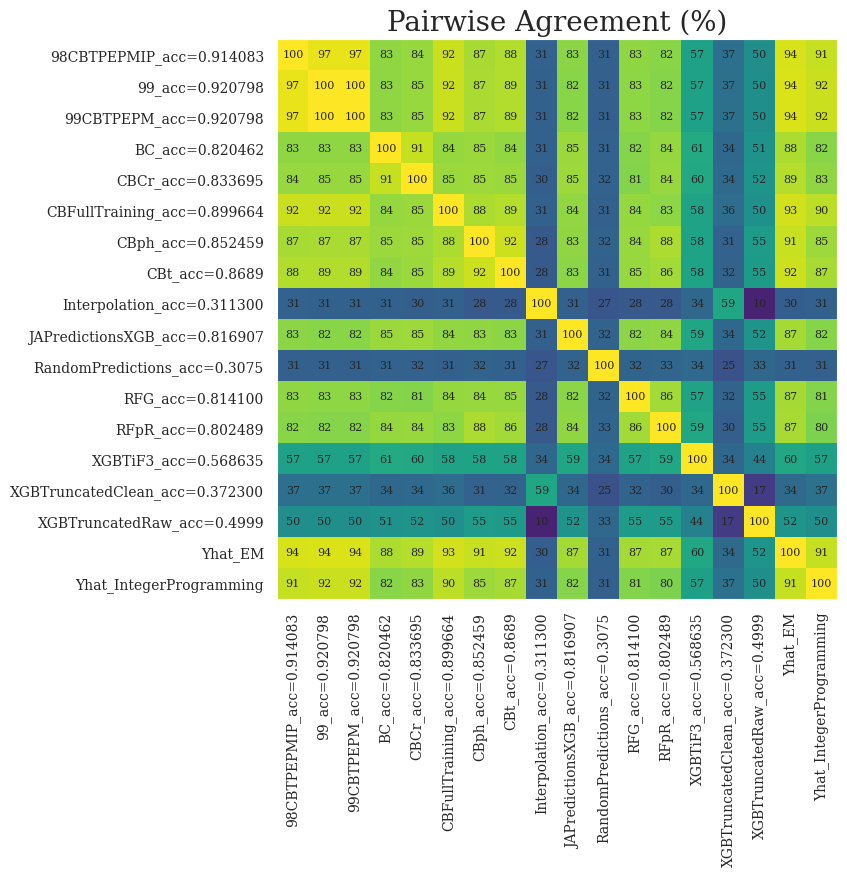

In [26]:


A, N = compute_pairwise_agreement(series_list)

# Heatmap (single-axes plot, no explicit colors)
fig = plt.figure(figsize=(max(6, 0.5*len(A)), max(5, 0.5*len(A))))
ax = plt.gca()
im = ax.imshow(A.values, vmin=0, vmax=100, cmap="viridis")  # fixed scale 0–100
plt.title("Pairwise Agreement (%)")
plt.xticks(ticks=np.arange(len(A)), labels=A.columns, rotation=90)
plt.yticks(ticks=np.arange(len(A)), labels=A.index)



# optional annotations (rounded)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        v = A.iat[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.grid(False)
plt.show()
